<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/10_Function_Transformer/2_Power_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power Transformer
## a.Box-cox
## b.Yeo-Johnson

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [98]:
df = pd.read_csv("/content/concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [99]:
df.shape

(1030, 9)

In [100]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [101]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [102]:
x=df.drop(columns='Strength')
y=df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((824, 8), (206, 8))

In [103]:
# applying Regression without any transformation

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

0.627553179231485

In [104]:
# Cross checking with cross val score

lr = LinearRegression()
np.mean(cross_val_score(lr, x, y, scoring='r2'))  # 10 time testing

np.float64(0.46099404916628606)

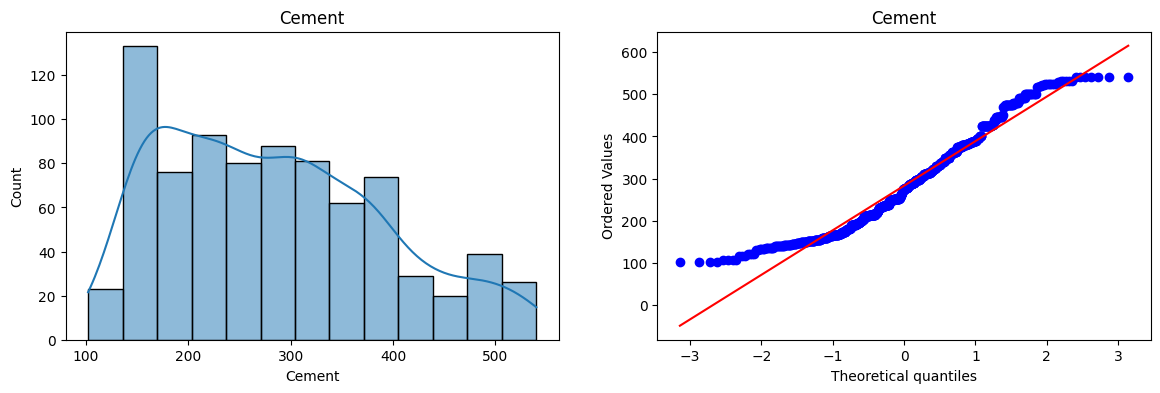

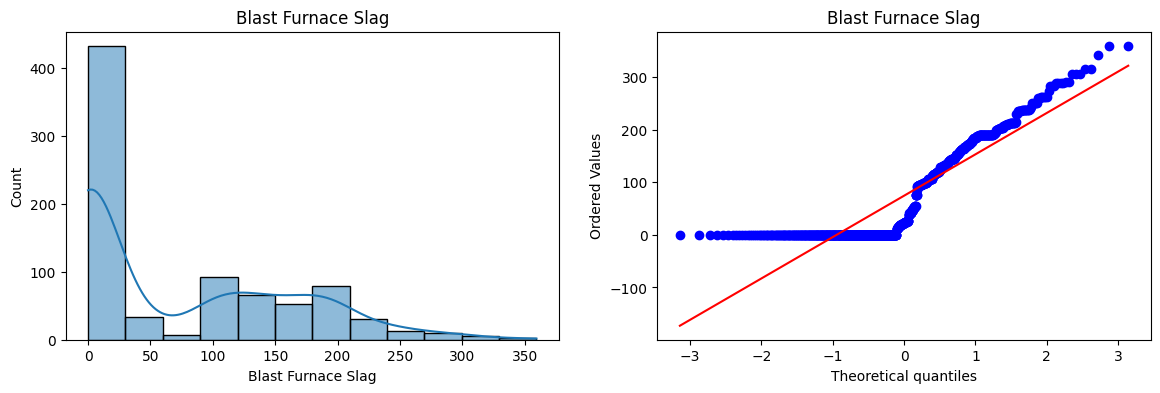

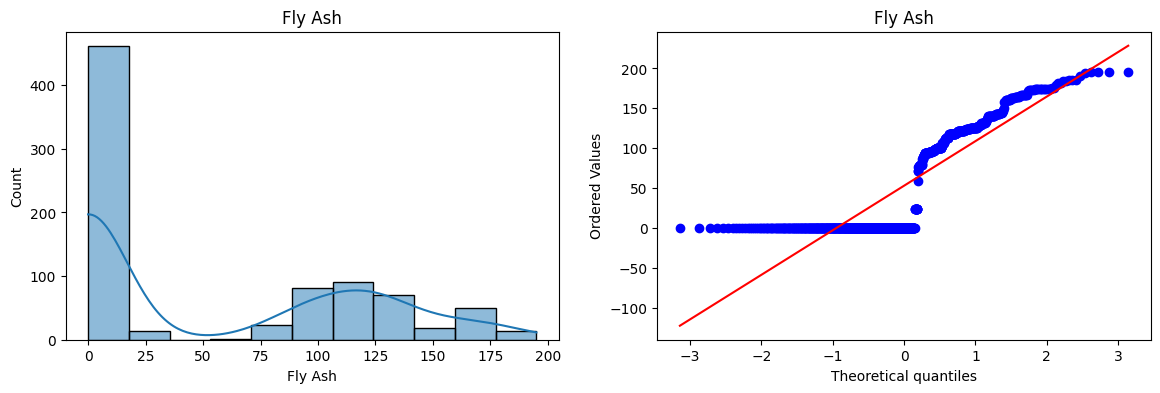

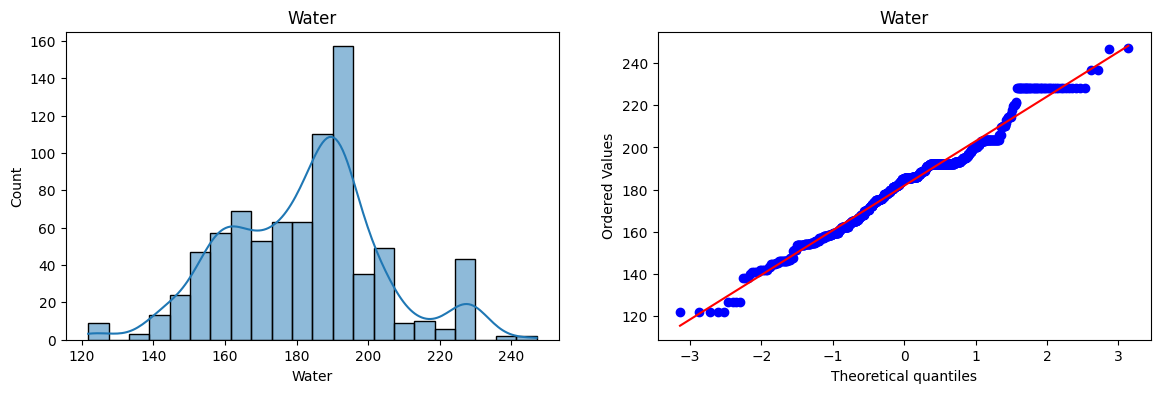

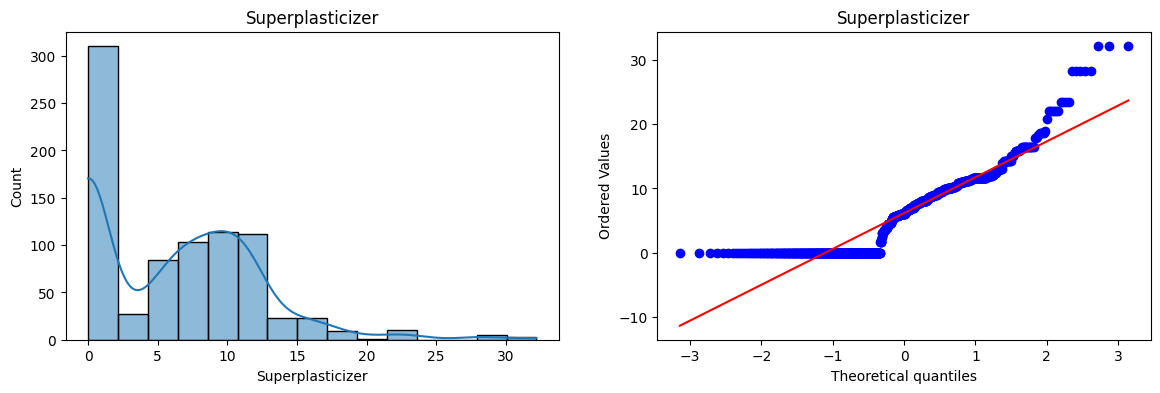

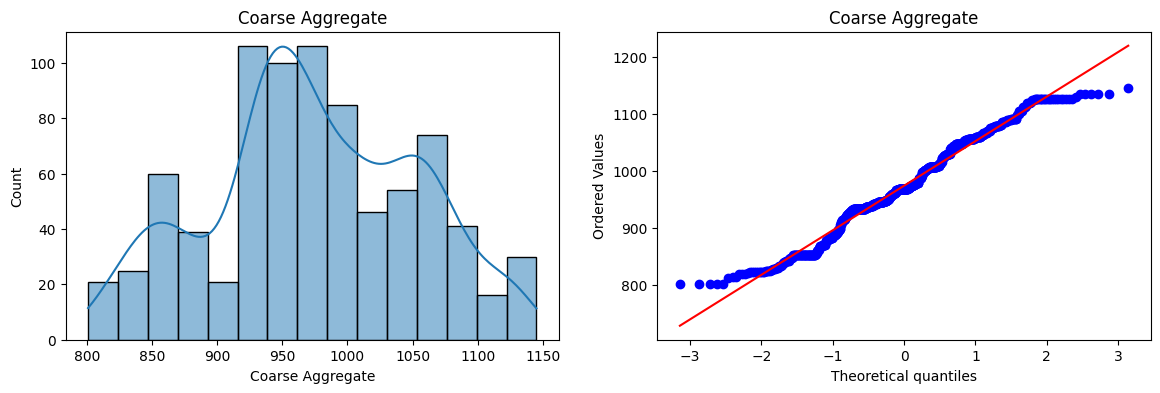

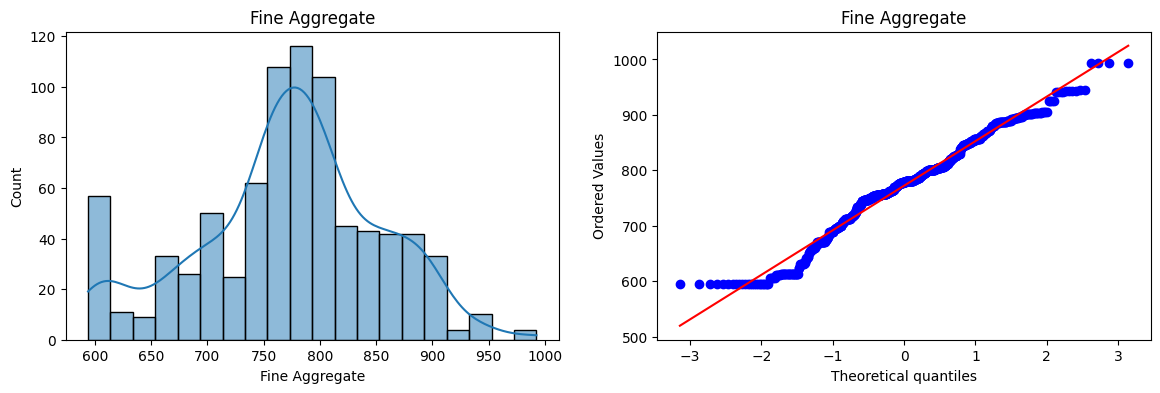

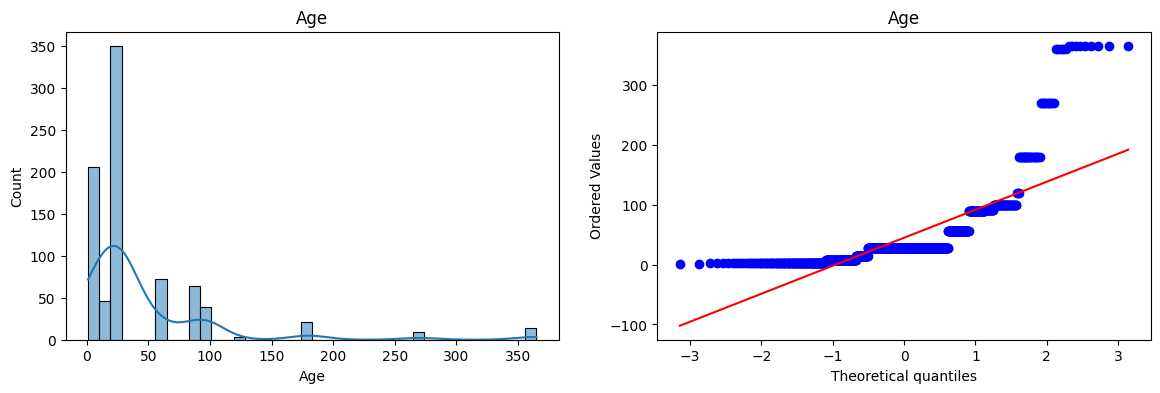

In [105]:
for col in X_train.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(1,2,1)
  sns.histplot(X_train[col], kde=True)
  plt.title(col)
  plt.subplot(1,2,2)
  stats.probplot(X_train[col], dist='norm', plot=plt)
  plt.title(col)
  plt.show()

In [106]:
# Applying box-cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

# convert into data frame in term of the box-cox so we analyse
pd.DataFrame({'cols':X_train.columns, 'box_cox_lambdas': pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [107]:
# applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test, y_pred2)

0.8047824993083206

In [108]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(x+0.0000001)   # 0.0000001 add then the zero values become 0.0000001

lr = LinearRegression()

np.mean(cross_val_score(lr, X_transformed, y, scoring='r2'))

np.float64(0.6658537935432477)

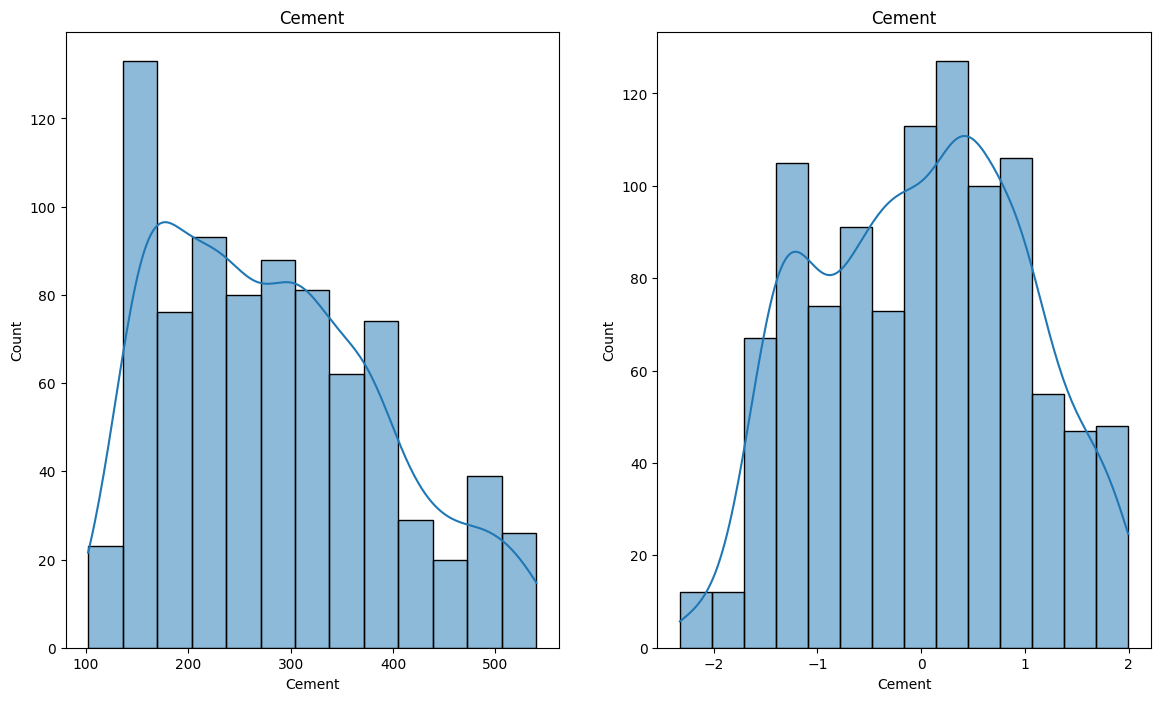

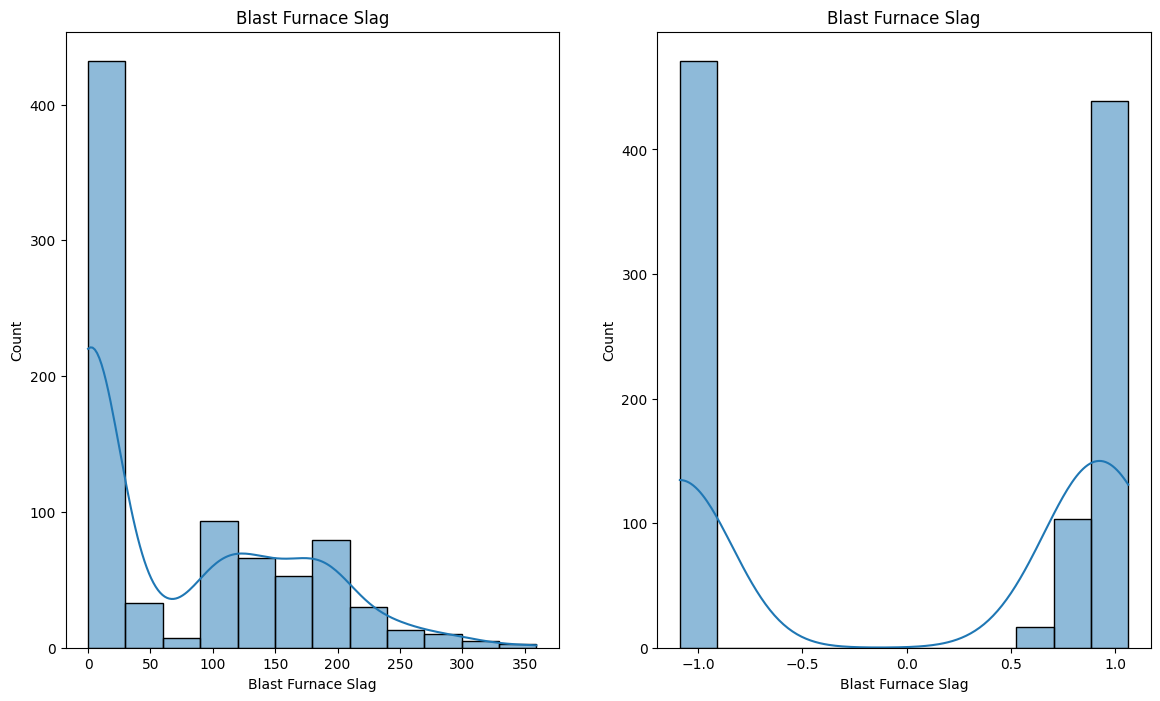

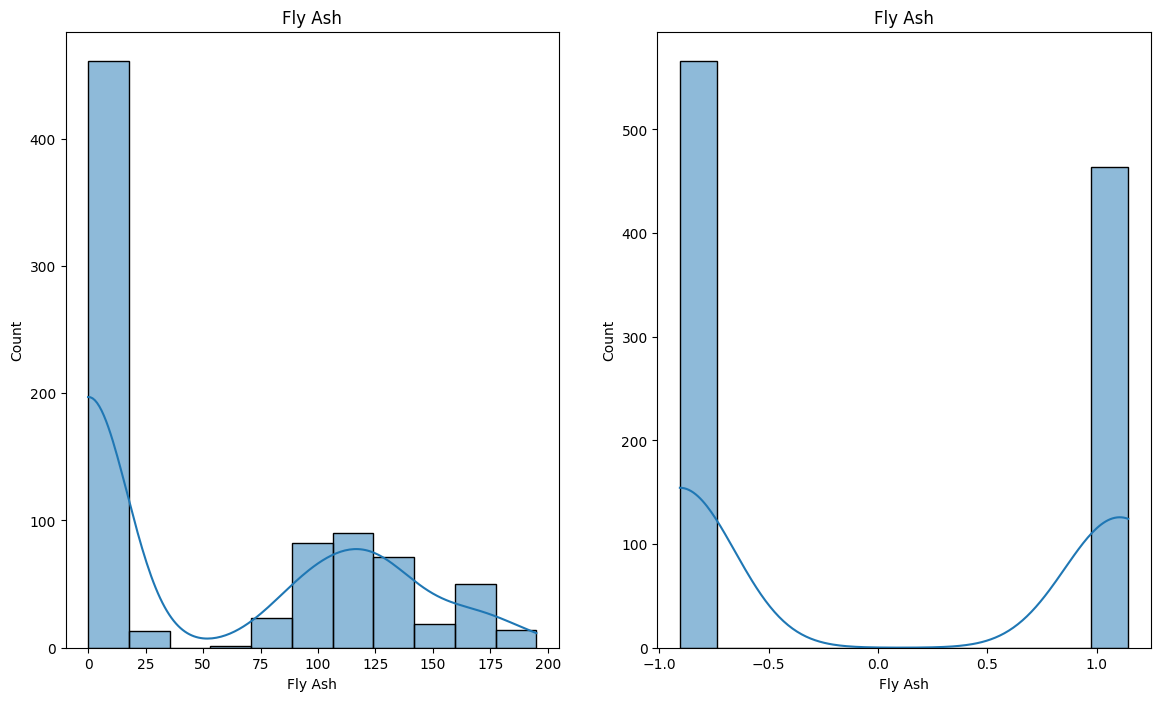

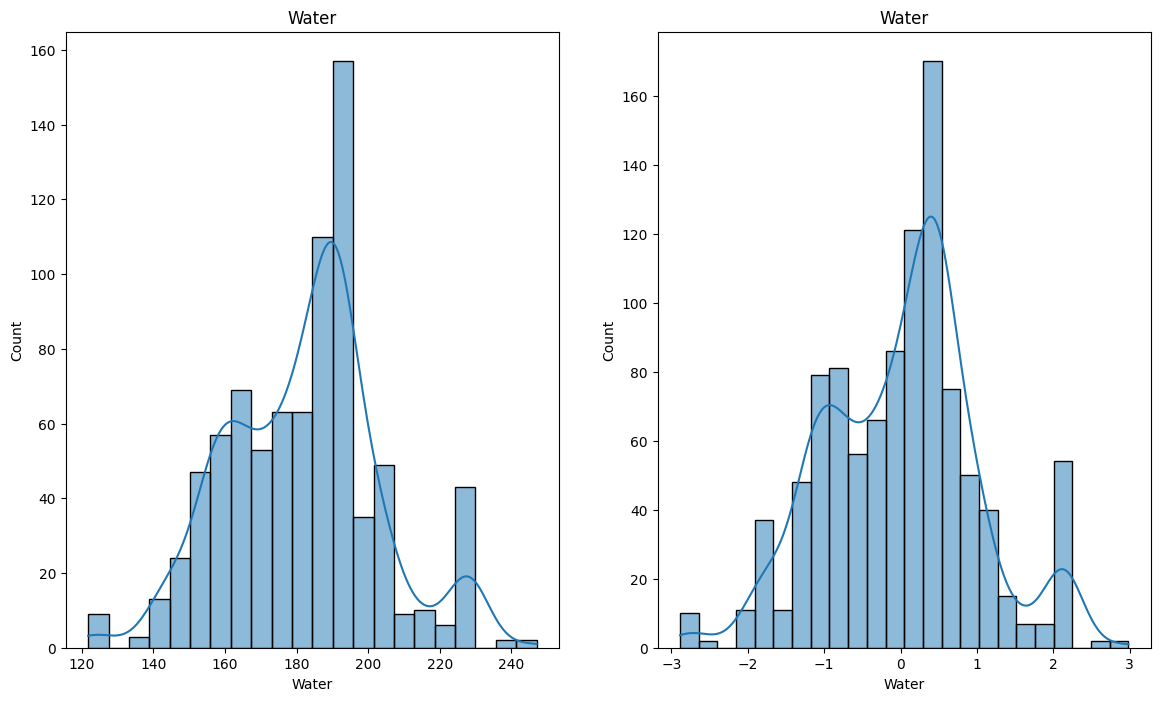

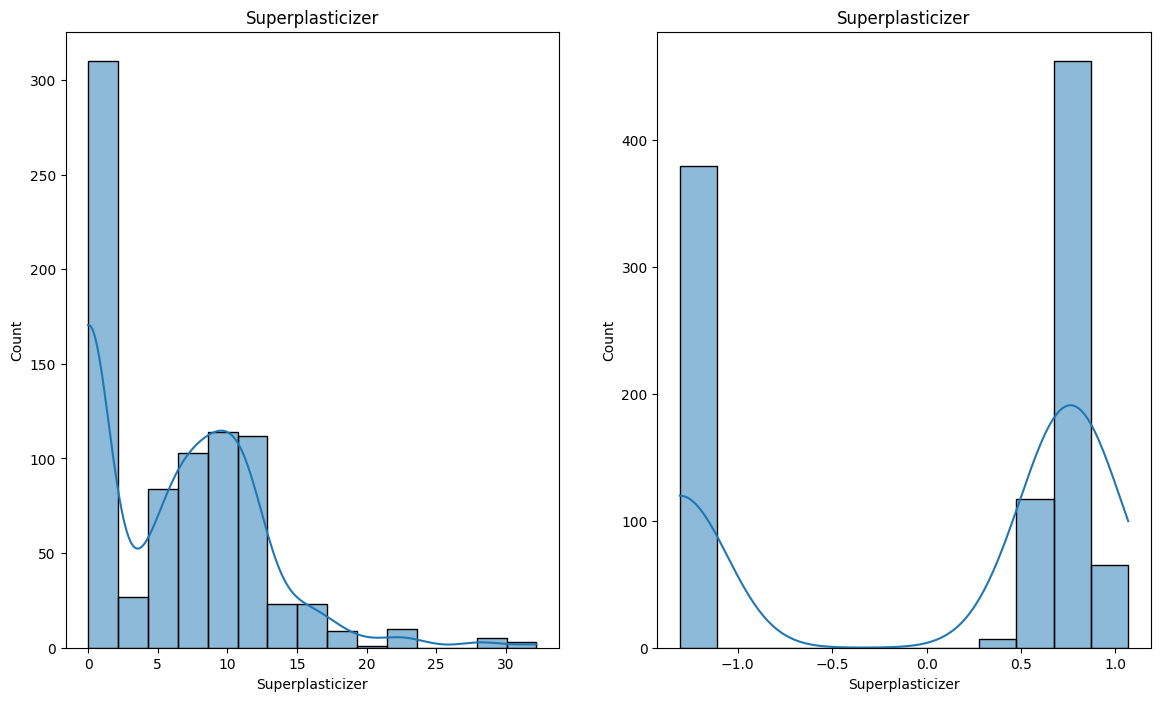

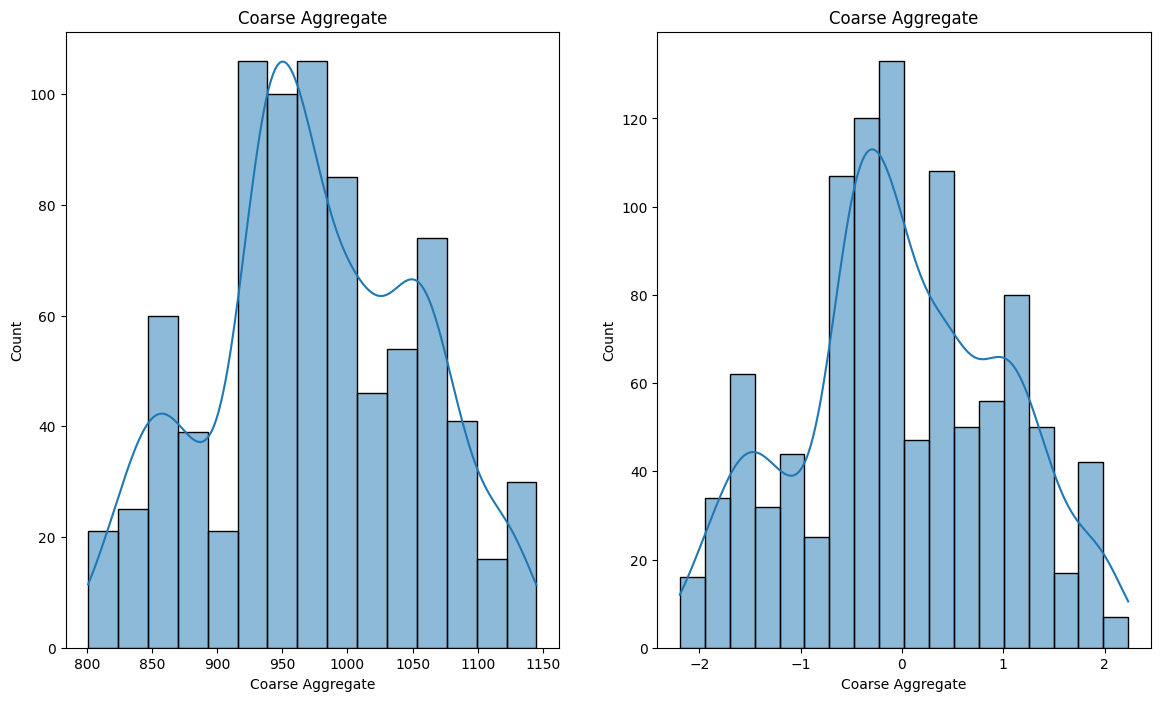

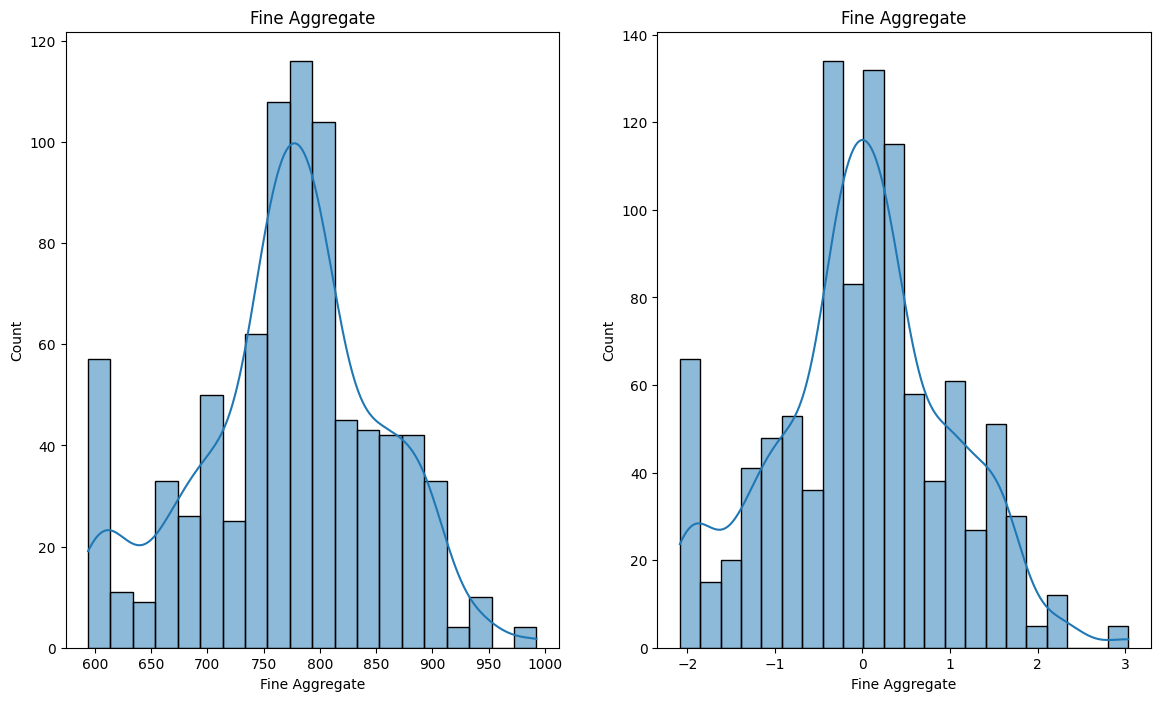

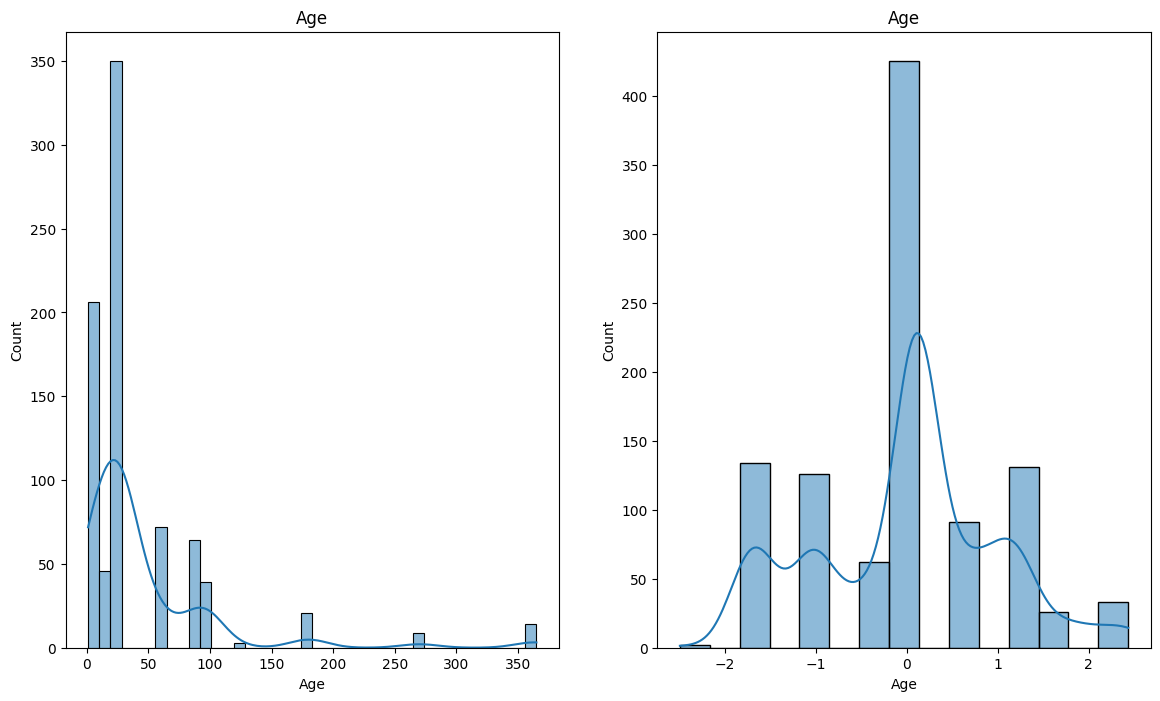

In [109]:
# convet the numpy array to dataframe

X_transformed = pd.DataFrame(X_transformed, columns=X_train.columns)
X_transformed

for col in X_transformed.columns:

  plt.figure(figsize=(14,8))
  plt.subplot(1,2,1)
  sns.histplot(X_train[col], kde=True)
  plt.title(col)
  plt.subplot(1,2,2)
  sns.histplot(X_transformed[col], kde=True)
  plt.title(col)

In [110]:
# Applying yeo-johnson Transform
# it handl negative and zero value
pt1 = PowerTransformer()   # by default yeo-johnson

X_train_transformed1 = pt1.fit_transform(X_train)
X_test_transformed1 = pt1.transform(X_test)

# convert into data frame in term of the yeo-johnson so we analyse
pd.DataFrame({'cols':X_train.columns, 'yeo_johnson_lambdas': pt1.lambdas_})

# applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed1, y_train)

y_pred2 = lr.predict(X_test_transformed1)

r2_score(y_test, y_pred2)

0.8161906512004999

In [111]:
pd.DataFrame({'cols':X_train.columns, 'yeo_johnson_lambdas': pt1.lambdas_})

,cols,yeo_johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [112]:
# Using cross val score

pt1 = PowerTransformer()
X_transformed1 = pt1.fit_transform(x)

lr = LinearRegression()

np.mean(cross_val_score(lr, X_transformed1, y, scoring='r2'))

np.float64(0.6834625141500866)

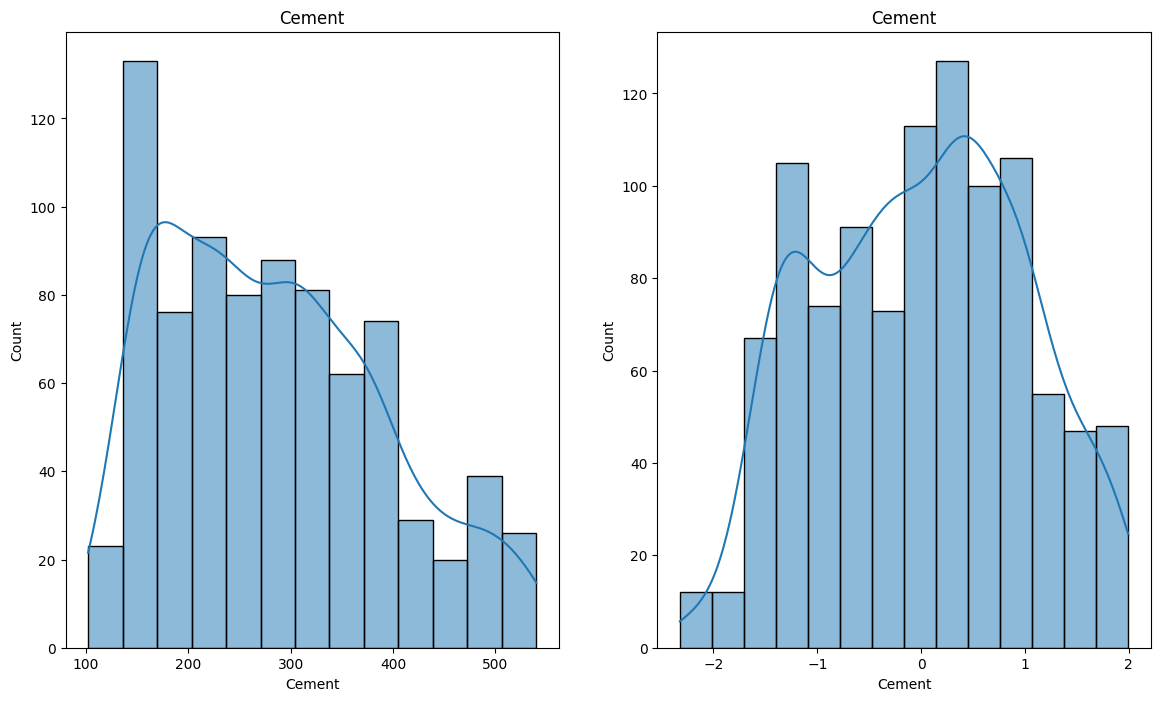

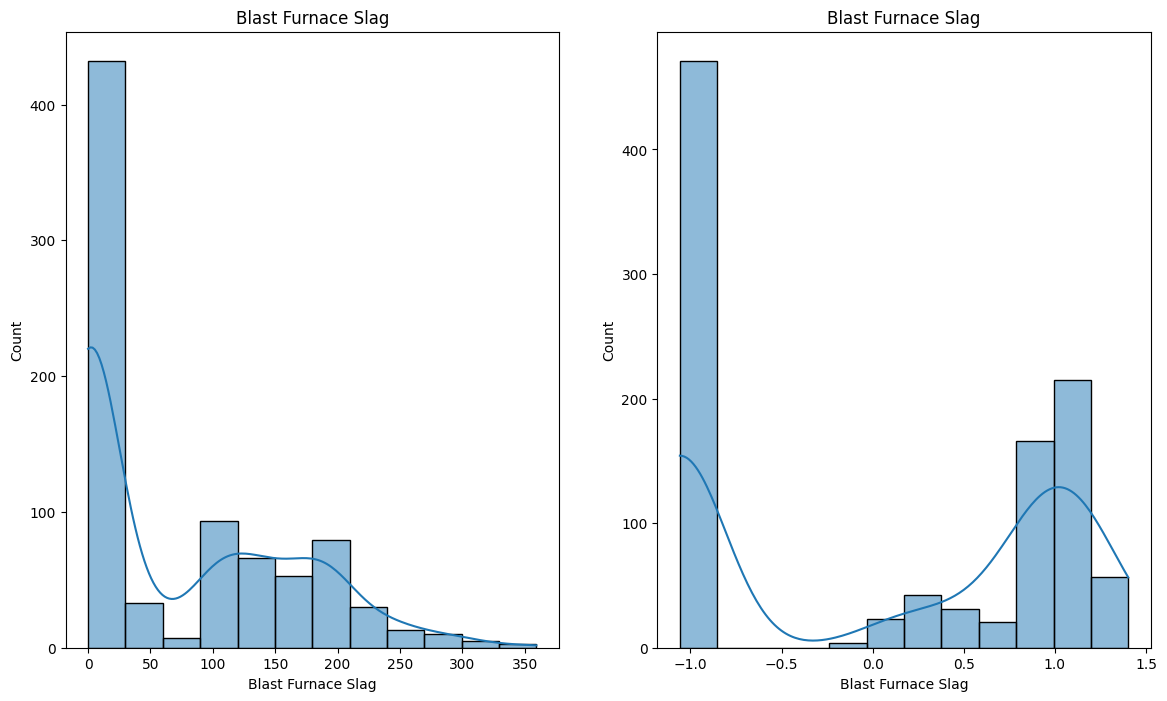

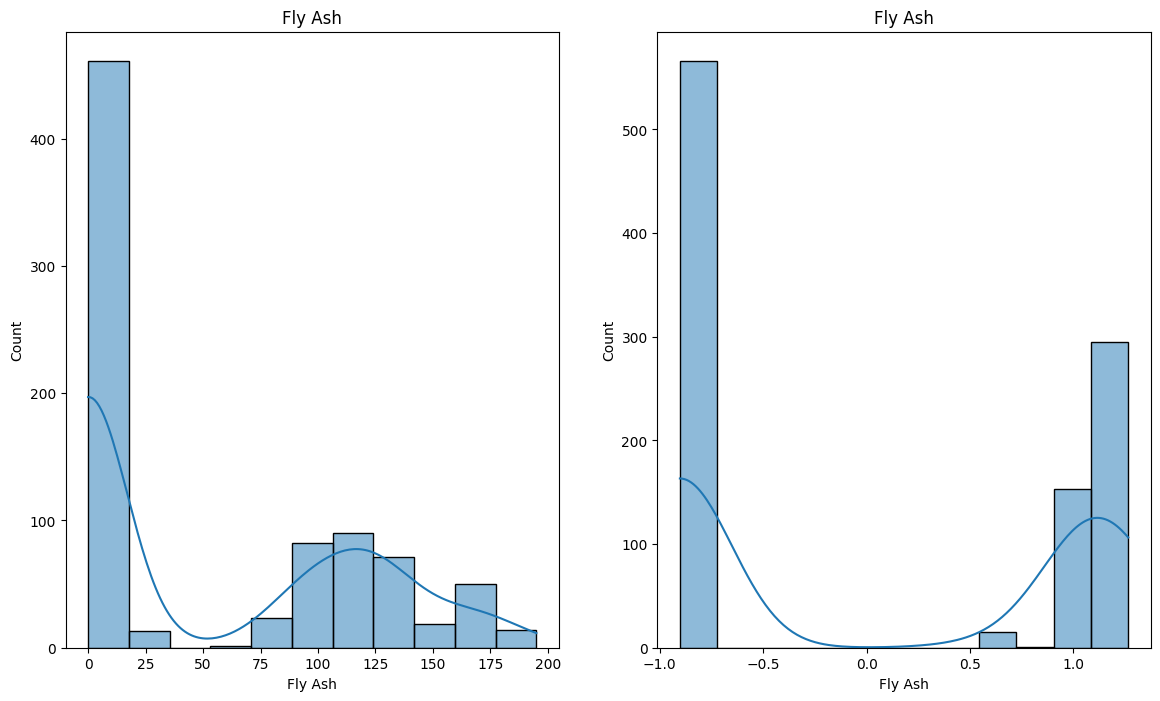

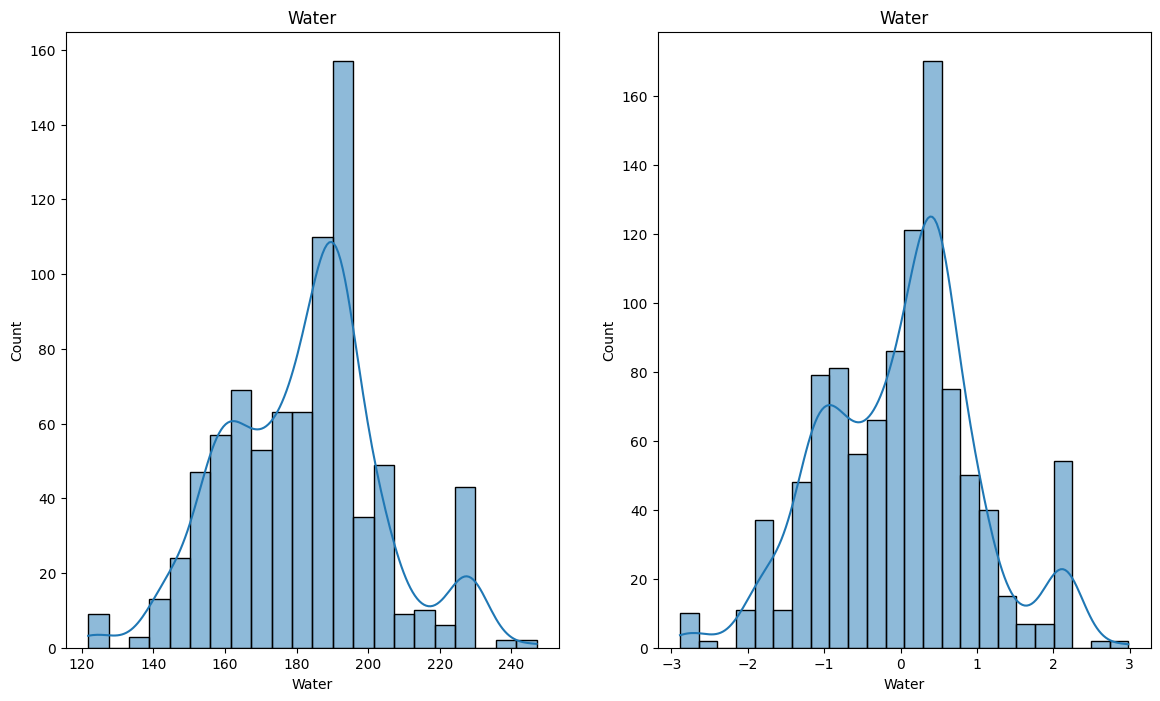

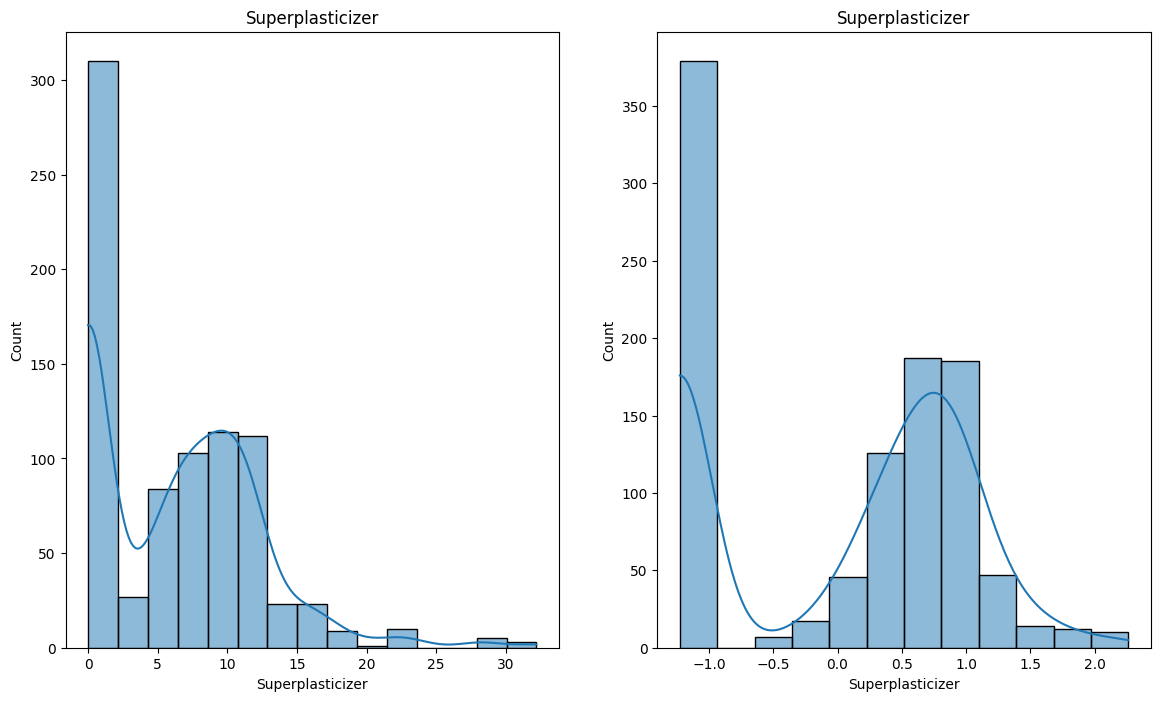

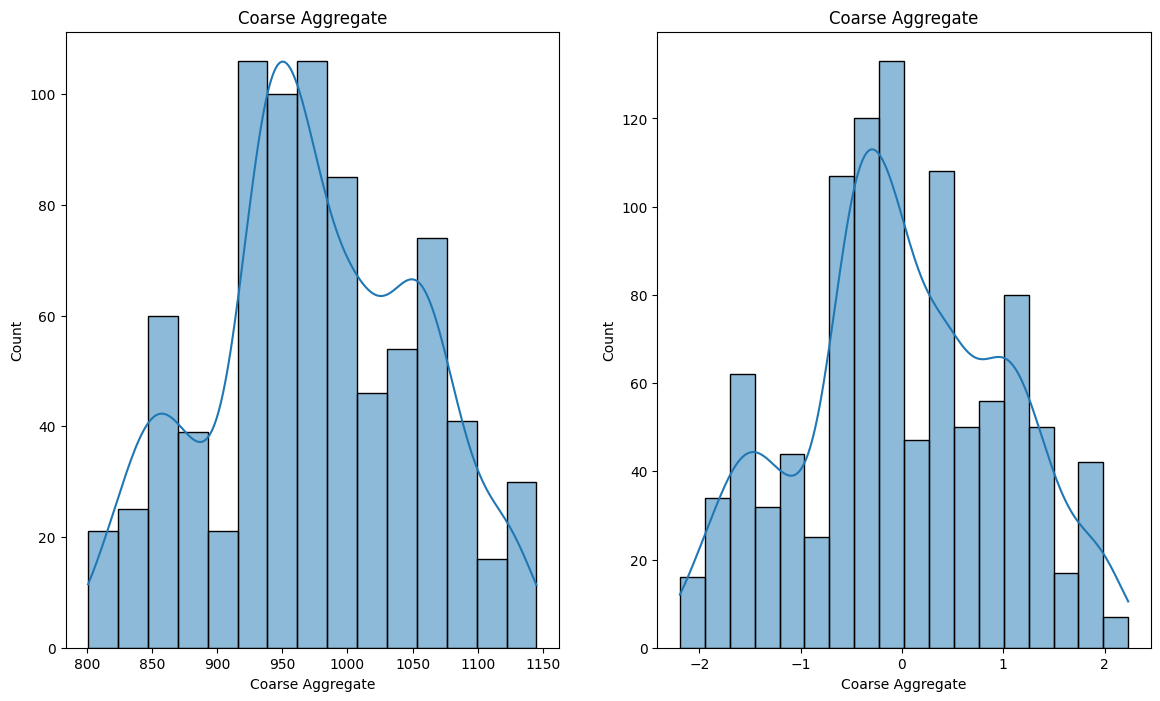

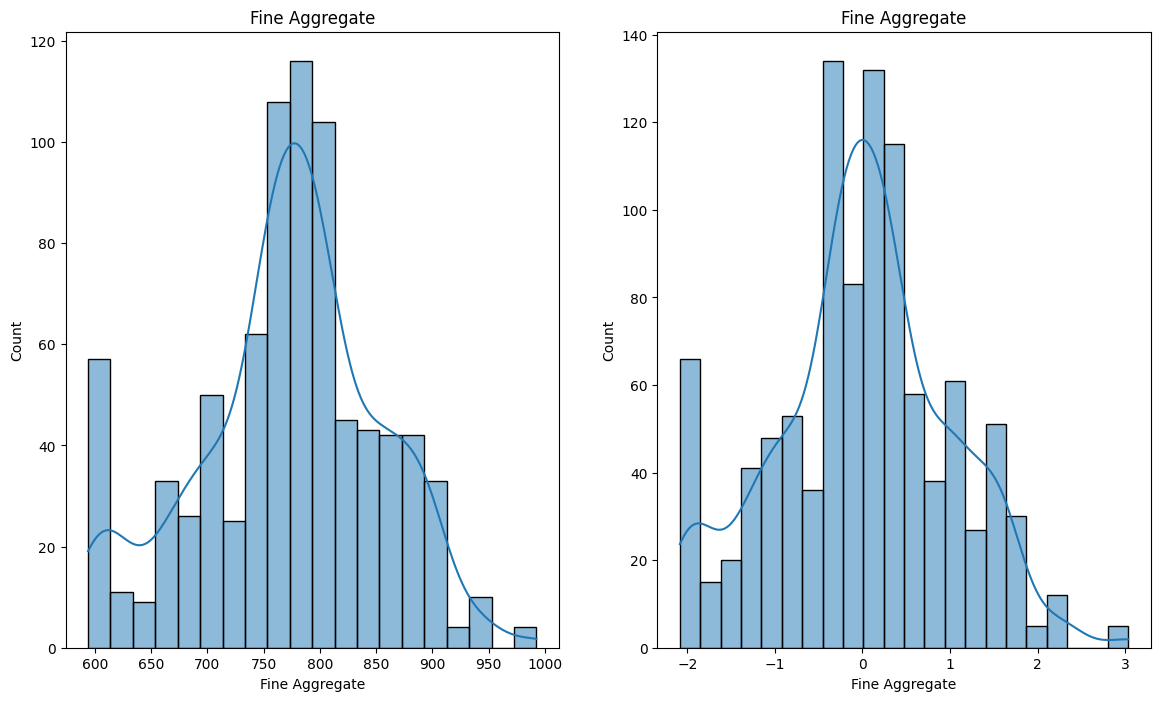

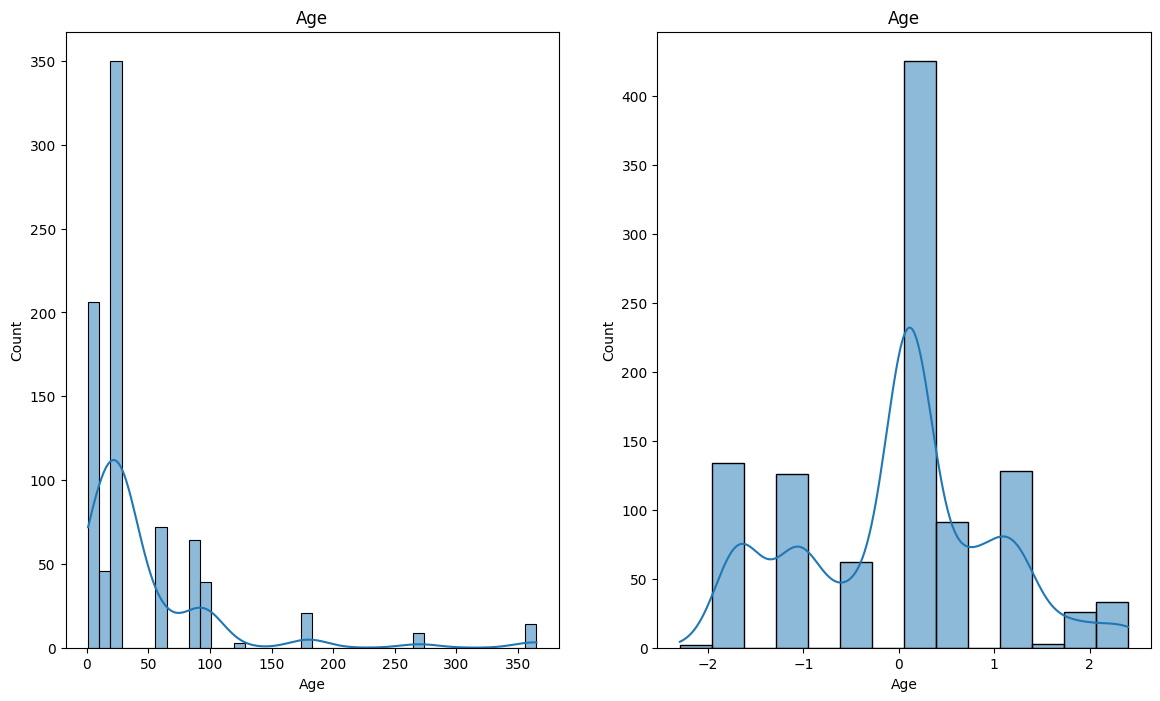

In [113]:
# convet the numpy array to dataframe

X_transformed1 = pd.DataFrame(X_transformed1, columns=X_train.columns)
X_transformed1

for col in X_transformed1.columns:

  plt.figure(figsize=(14,8))
  plt.subplot(1,2,1)
  sns.histplot(X_train[col], kde=True)
  plt.title(col)
  plt.subplot(1,2,2)
  sns.histplot(X_transformed1[col], kde=True)
  plt.title(col)

In [115]:
pd.DataFrame({'cols':X_train.columns, 'box_cox_lambdas': pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.172271
1,Blast Furnace Slag,0.022924
2,Fly Ash,-0.028797
3,Water,0.809568
4,Superplasticizer,0.087911
5,Coarse Aggregate,1.129167
6,Fine Aggregate,1.829625
7,Age,0.048975


In [118]:
print(hasattr(pt1, 'lambdas_'))

True


In [119]:
print(len(X_train.columns))
print(len(pt.lambdas_))
print(len(pt1.lambdas_))

8
8
8


In [120]:
pd.DataFrame({
    'cols': X_train.columns,
    'box_cox_lambdas': pt.lambdas_,
    'yeo_johnson_lambdas': pt1.lambdas_
})

,cols,box_cox_lambdas,yeo_johnson_lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.022924,0.016633
2,Fly Ash,-0.028797,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.087911,0.264160
5,Coarse Aggregate,1.129167,1.129395
6,Fine Aggregate,1.829625,1.830763
7,Age,0.048975,0.001771


In [116]:
print(type(pt1))

<class 'sklearn.preprocessing._data.PowerTransformer'>


In [117]:
print(type(pt))

<class 'sklearn.preprocessing._data.PowerTransformer'>
